**Objective:** Read in model output and analyze travel distance and times for coastal water discharge, using particle backtracking

In [6]:
import numpy as np
import matplotlib.pyplot as pl

import lib.read_vtu_file

from lib.grompy_lib import get_normal_flux_to_bnd

# Read model output file

In [7]:

fn = "model_output/median_case/vtk_files/runS0_L_8045.0_ts0_Elements.vtu"

fnf = "model_output/median_case/vtk_files/runS0_L_8045.0_ts0_FaceElements.vtu"

xy_pts, conn, pt_var_names, pt_var_arrays, cell_var_names, cell_var_arrays = \
	lib.read_vtu_file.read_vtu_file(fn)

xy_pts_face, conn_face, pt_var_names_face, pt_var_arrays_face, cell_var_names_face, cell_var_arrays_face = \
	lib.read_vtu_file.read_vtu_file(fnf)



found var name:  active_concentration_bnd
found var name:  active_seepage_bnd
found var name:  concentration
found var name:  h
found var name:  nodal_flux
found var name:  nodal_flux_surface
found var name:  pressure
found var name:  sea_surface
found var name:  specified_pressure_bnd
found var name:  surface
found var name:  flux
found var name:  kx
found var name:  ky
found var name:  qx
found var name:  qy
found var name:  flux_surface_norm
found var name:  recharge_bnd


# Reconstruct boundary fluxes

In [8]:
# find top bnd fluxes
print('find top bnd fluxes')
if 'nodal_flux_surface' in pt_var_names:
	f_ind = pt_var_names.index('nodal_flux')
nfx = pt_var_arrays[f_ind][:, 0]
nfy = pt_var_arrays[f_ind][:, 1]
nodal_flux_init = pt_var_arrays[f_ind]

#
year = 365.24 * 24 * 3600
nodal_flux = nodal_flux_init * year

nodata = -99999
if 'surface' in pt_var_names:
	sf_ind = pt_var_names.index('surface')
	bnd_ind = pt_var_arrays[sf_ind] == 1
else:
	sf_ind = pt_var_names.index('nodal_flux_surface')
	nfx = pt_var_arrays[sf_ind][:, 0]
	nfy = pt_var_arrays[sf_ind][:, 1]
	bnd_ind = (nfx > nodata) & (nfy > nodata)

topxy = xy_pts[:, :][bnd_ind]
x_order = np.argsort(topxy[:, 0])
top_xy_sorted = topxy[x_order]
nodal_flux_top_sorted = nodal_flux[bnd_ind][x_order]
#nfy_top_sorted = nfy[bnd_ind][x_order]

slope = np.diff(top_xy_sorted[:, 1]) / np.diff(top_xy_sorted[:, 0])
slope_mean = slope.mean()

# find h at top bnd
h = pt_var_arrays[pt_var_names.index('h')]
h_top = h[bnd_ind][x_order]

print('rotate flux')
nodal_flux_rotated = \
	get_normal_flux_to_bnd(nodal_flux_top_sorted,
							top_xy_sorted)


find top bnd fluxes
rotate flux


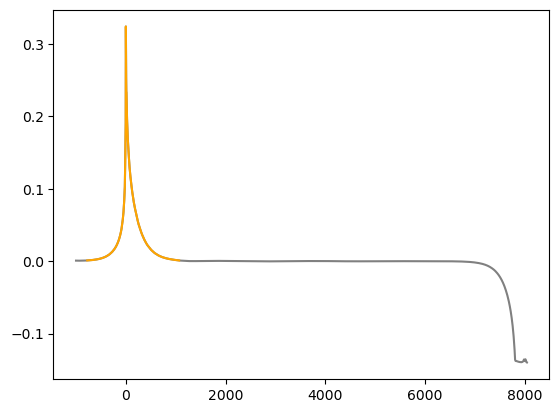

In [9]:
fig, ax = pl.subplots(1, 1)	
ind = nodal_flux_rotated[:, 1] > 0.001
ax.plot(top_xy_sorted[:, 0], nodal_flux_rotated[:, 1], color="gray")
ax.plot(top_xy_sorted[:, 0][ind], nodal_flux_rotated[:, 1][ind], color="orange")

# Plan: use streamplot to calculate streamlines instead of coding from scratch

https://stackoverflow.com/questions/75406627/python-streamline-algorithm

In [27]:
seed_pts_xy = top_xy_sorted[ind]

qx, qy = cell_var_arrays[cell_var_names.index('qx')], cell_var_arrays[cell_var_names.index('qy')]

n_seed_pts = seed_pts_xy.shape[0]

nt_max = 100

dt = 100.0 * year

path_array = np.full((nt_max, n_seed_pts, 2), np.nan)

path_array[0] = seed_pts_xy[:, :2]

qx_seed_pts = np.zeros(n_seed_pts)
qy_seed_pts = np.zeros(n_seed_pts)

for i in range(1, nt_max):
	for j in range(n_seed_pts):
		xp, yp = path_array[i-1, j]
		dist = np.sqrt((xy_pts[:, 0] - xp)**2 + (xy_pts[:, 1] - yp)**2)
		#ix_nearest_particle = np.argmin(dist)
		ix_nearest_particle = np.unravel_index(np.argmin(dist), dist.shape)

		dist_nearest_particle = dist[ix_nearest_particle]
		
		qx_seed_pt = qx[ix_nearest_particle]
		qy_seed_pt = qy[ix_nearest_particle]
		
		x_new = xp - qx_seed_pt * dt
		y_new = yp - qy_seed_pt * dt
		path_array[i, j, :] = [x_new, y_new]


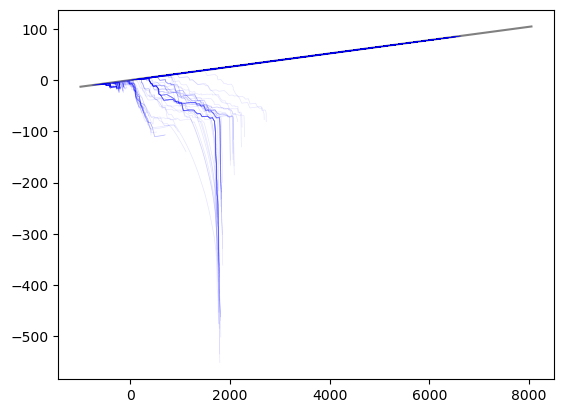

In [28]:
fig, ax = pl.subplots(1, 1)	
ind = nodal_flux_rotated[:, 1] > 0.001
ax.plot(top_xy_sorted[:, 0], top_xy_sorted[:, 1], color="gray")
#ax.plot(top_xy_sorted[:, 0][ind], nodal_flux_rotated[:, 1][ind], color="orange")

for i in range(n_seed_pts):
	ax.plot(path_array[:, i, 0], path_array[:, i, 1], color="blue", alpha=0.1, lw=0.5)


In [16]:
#ix = np.argmax(path_array[:, :, 1])
max_idx = np.unravel_index(np.argmax(path_array[:, :, 1]), path_array[:, :, 1].shape)


path_array[:, max_idx[1]]

array([[1068.192     ,   13.88649   ],
       [1068.75682802,   13.89383815],
       [1069.32165604,   13.9011863 ],
       [1069.88648407,   13.90853445],
       [1070.45131209,   13.9158826 ],
       [1071.01613127,   13.92322969],
       [1071.58095046,   13.93057678],
       [1072.14576965,   13.93792387],
       [1072.71058883,   13.94527096],
       [1073.27540802,   13.95261805],
       [1073.8402272 ,   13.95996514],
       [1074.40504923,   13.96731206],
       [1074.96987126,   13.97465898],
       [1075.53469328,   13.9820059 ],
       [1076.09951531,   13.98935282],
       [1076.66433733,   13.99669974],
       [1077.22915936,   14.00404666],
       [1077.79398139,   14.01139357],
       [1078.35878416,   14.01874061],
       [1078.92358694,   14.02608765],
       [1079.48838972,   14.03343468],
       [1080.05319249,   14.04078172],
       [1080.61799527,   14.04812876],
       [1081.18279805,   14.05547579],
       [1081.74760082,   14.06282283],
       [1082.31241275,   

In [18]:
xp, yp = 1068.192     ,   13.88649 
dist = np.sqrt((xy_pts[:, 0] - xp)**2 + (xy_pts[:, 1] - yp)**2)
#ix_nearest_particle = np.argmin(dist)
ix_nearest_particle = np.unravel_index(np.argmin(dist), dist.shape)

dist_nearest_particle = dist[ix_nearest_particle]

qx_seed_pt = qx[ix_nearest_particle]
qy_seed_pt = qy[ix_nearest_particle]


In [23]:
qx_seed_pt

np.float64(-1.789881e-08)